# Prática 2 - Classificação de Tickets de Incidentes

**Estudo de Caso 2 — Minicurso "Inteligência Artificial aplicada à Resposta a Incidentes"**

Este notebook realiza a classificação de 24 tickets sintéticos, empregando a mesma
abordagem utilizada na classificação da base real: **classificação livre, zero-shot e
one-shot**.


O arquivo `tickets_sinteticos.csv`, contendo os tickets utilizados neste notebook, pode ser compartilhado
livremente, pois os tickets são 100% fictícios. Dessa forma, não há restrição quanto à apresentação de
seu conteúdo completo.

    

> **Pré-requisito:** coloque o arquivo `tickets_sinteticos.csv` na mesma pasta deste
> notebook.

## 0. Instalando dependências

In [1]:
%pip install google-genai pandas matplotlib --quiet


Note: you may need to restart the kernel to use updated packages.


## 1. Taxonomia de referência

In [2]:
TAXONOMIA = {
    "CAT1":  "Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores",
    "CAT2":  "Malware — infecção por código malicioso que compromete dispositivos ou dados",
    "CAT3":  "Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes",
    "CAT4":  "Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis",
    "CAT5":  "Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos",
    "CAT6":  "Abuso Interno — ações intencionais ou negligentes de usuários internos",
    "CAT7":  "Engenharia Social — engano de pessoas para obter acesso ou informações",
    "CAT8":  "Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais",
    "CAT9":  "Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configurações",
    "CAT10": "Uso Indevido de Recursos — uso não autorizado de sistemas para outros fins",
    "CAT11": "Problema de Fornecedor/Terceiro — incidente originado por falha de segurança de terceiros",
    "CAT12": "Tentativa de Intrusão — tentativas hostis de invasão ainda não confirmadas como bem-sucedidas",
}
for cod, desc in TAXONOMIA.items():
    print(f"{cod}: {desc}")


CAT1: Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores
CAT2: Malware — infecção por código malicioso que compromete dispositivos ou dados
CAT3: Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes
CAT4: Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis
CAT5: Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos
CAT6: Abuso Interno — ações intencionais ou negligentes de usuários internos
CAT7: Engenharia Social — engano de pessoas para obter acesso ou informações
CAT8: Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais
CAT9: Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configurações
CAT10: Uso Indevido de Recursos — uso não autorizado de sistemas para outros fins
CAT11: Problema de Fornecedor/Terceiro — incidente originado por falha de segurança de terceiros
CAT12: Tentativ

## 2. Carregando os tickets e separando exemplos one-shot
Como a base de tickets é pequena (24 tickets), apenas 4 amostras one-shot
são usadas, sendo uma de cada categoria.

In [3]:
import pandas as pd

df = pd.read_csv("tickets_sinteticos.csv")
print(f"{len(df)} tickets sintéticos carregados.")
print(df["categoria"].value_counts().sort_index())

# Apenas 4 exemplos, escolhidos com propósito didático
# CAT3: T023
# CAT4: T022
# CAT5: T017
# CAT12: T010

exemplos_ids = ["T017", "T023", "T010", "T022"]

df_exemplos = df[df["id"].isin(exemplos_ids)].copy()
df_avaliacao = df[~df["id"].isin(exemplos_ids)].reset_index(drop=True)

EXEMPLOS_ONE_SHOT = [
    {"texto": row["texto"], "categoria": row["categoria"]}
    for _, row in df_exemplos.iterrows()
]

print(f"\nExemplos one-shot escolhidos ({len(EXEMPLOS_ONE_SHOT)}):")
for _, row in df_exemplos.sort_values("categoria", key=lambda s: s.str.replace("CAT", "").astype(int)).iterrows():
    print(f"  {row['categoria']}: {row['id']}")
print(f"\nAvaliação: {len(df_avaliacao)} tickets")


24 tickets sintéticos carregados.
categoria
CAT1     1
CAT10    1
CAT11    1
CAT12    3
CAT2     2
CAT3     3
CAT4     2
CAT5     5
CAT6     1
CAT7     2
CAT8     1
CAT9     2
Name: count, dtype: int64

Exemplos one-shot escolhidos (4):
  CAT3: T023
  CAT4: T022
  CAT5: T017
  CAT12: T010

Avaliação: 20 tickets


## 3. Configuração da API (Gemini)

Precisa de uma chave de API do Google AI Studio
(`GOOGLE_GENERATIVE_AI_API_KEY`).


In [4]:
import os

# Opção 1: defina a variável de ambiente antes de abrir o Jupyter
#   export GOOGLE_GENERATIVE_AI_API_KEY="sua-chave-aqui"
#
# Opção 2: descomente a linha abaixo e cole sua chave
# os.environ["GOOGLE_GENERATIVE_AI_API_KEY"] = "sua chave aqui"

API_KEY = os.environ.get("GOOGLE_GENERATIVE_AI_API_KEY")
MODEL_NAME = os.environ.get("GOOGLE_GENERATIVE_MODEL", "gemini-3.1-flash-lite")

if API_KEY:
    from google import genai
    client = genai.Client(api_key=API_KEY)
    print(f"Cliente Gemini configurado. Modelo: {MODEL_NAME}")
else:
    client = None
    print("Nenhuma API key encontrada.")


Cliente Gemini configurado. Modelo: gemini-3.1-flash-lite


## 4. Funções auxiliares

In [5]:
import re
import time
from collections import deque


def montar_prompt_livre(ticket_texto: str) -> str:
    return f"""Você é um analista de SOC. Leia o ticket abaixo e diga, com suas próprias palavras, que tipo de incidente de segurança é esse — não fornecemos nenhuma lista de categorias.

Ticket:
\"\"\"
{ticket_texto}
\"\"\"

Responda em formato JSON, apenas com as chaves "categoria" (um rótulo curto, 2 a 4 palavras) e "justificativa" (uma frase curta)."""


def montar_prompt_zero_shot(ticket_texto: str, taxonomia: dict) -> str:
    categorias_str = "\n".join(f"- {cod}: {desc}" for cod, desc in taxonomia.items())
    return f"""Você é um analista de SOC especialista em categorização de incidentes de segurança.

Classifique o ticket abaixo em UMA das categorias a seguir, segundo o NIST SP 800-61 Rev. 3:

{categorias_str}

Ticket:
\"\"\"
{ticket_texto}
\"\"\"

Responda em formato JSON, apenas com as chaves "categoria" (o código, ex: CAT1) e "justificativa" (uma frase curta)."""


def montar_prompt_com_exemplos(ticket_texto: str, taxonomia: dict, exemplos: list) -> str:
    categorias_str = "\n".join(f"- {cod}: {desc}" for cod, desc in taxonomia.items())
    exemplos_str = "\n\n".join(
        f'Ticket: \"{ex["texto"][:400]}...\"\nResposta: {{"categoria": "{ex["categoria"]}"}}'
        for ex in exemplos
    )
    return f"""Você é um analista de SOC especialista em categorização de incidentes de segurança.

Classifique o ticket em UMA das categorias a seguir, segundo o NIST SP 800-61 Rev. 3:

{categorias_str}

Veja alguns exemplos já classificados:

{exemplos_str}

Agora classifique o novo ticket:
\"\"\"
{ticket_texto}
\"\"\"

Responda em formato JSON, apenas com as chaves "categoria" (o código, ex: CAT1) e "justificativa" (uma frase curta)."""


CODIGOS_TRANSITORIOS = {"429": 20, "503": 15, "500": 15, "502": 15, "504": 15}

RPM_LIMITE = 15
_historico_chamadas = deque()


def aguardar_janela_rpm(margem: int = 4):
    """Garante que nunca há mais de (RPM_LIMITE - margem) chamadas nos últimos 60s
    — conta TODAS as chamadas, inclusive retentativas após 429/503."""
    limite_seguro = RPM_LIMITE - margem
    agora = time.time()
    while _historico_chamadas and agora - _historico_chamadas[0] > 60:
        _historico_chamadas.popleft()
    if len(_historico_chamadas) >= limite_seguro:
        espera = 60 - (agora - _historico_chamadas[0]) + 1
        print(f"  [rpm: {len(_historico_chamadas)}/{limite_seguro} na última janela — aguardando {espera:.0f}s]")
        time.sleep(max(espera, 0))
    _historico_chamadas.append(time.time())


def classificar(prompt: str, max_tentativas: int = 5) -> str:
    if client is None:
        raise RuntimeError("Cliente Gemini não configurado.")
    for tentativa in range(1, max_tentativas + 1):
        aguardar_janela_rpm()
        try:
            resposta = client.models.generate_content(model=MODEL_NAME, contents=prompt)
            return resposta.text
        except Exception as e:
            erro_str = str(e)
            codigo = next((c for c in CODIGOS_TRANSITORIOS if c in erro_str), None)
            if codigo:
                espera = CODIGOS_TRANSITORIOS[codigo] * tentativa
                print(f"  [erro {codigo} — aguardando {espera}s ({tentativa}/{max_tentativas})]")
                time.sleep(espera)
            else:
                raise
    raise RuntimeError(f"Falhou após {max_tentativas} tentativas.")


def extrair_categoria(resposta_texto: str):
    match = re.search(r"CAT\d{1,2}", resposta_texto or "")
    return match.group(0) if match else None


def extrair_categoria_livre(resposta_texto: str) -> str:
    match = re.search(r'"categoria"\s*:\s*"([^"]+)"', resposta_texto or "")
    return match.group(1).strip() if match else (resposta_texto or "").strip()[:60]


SAMPLE_SIZE = len(df_avaliacao)  # 20 tickets de avaliação — já roda tudo por padrão


## 5. Rodando as três técnicas (com retomada automática)

Salva o resultado a cada ticket se a execução cair no meio, basta rodar
esta célula de novo: ela pula os ticketS já processados.


In [7]:
amostra = df_avaliacao.head(SAMPLE_SIZE)
print(f"Amostra: {len(amostra)} tickets.\n")

COLUNAS_SAIDA = ["id", "id_incidente", "esperado", "rotulo_livre", "zero_shot", "one_shot"]
ARQUIVO_SAIDA = "resultados_sinteticos.csv"

if os.path.exists(ARQUIVO_SAIDA):
    resultados = pd.read_csv(ARQUIVO_SAIDA).to_dict("records")
    ids_ja_feitos = {r["id"] for r in resultados}
    print(f"Retomando: {len(resultados)} ticket(s) já processados anteriormente, serão pulados.\n")
else:
    resultados = []
    ids_ja_feitos = set()

for _, row in amostra.iterrows():
    if row["id"] in ids_ja_feitos:
        continue

    linha = {"id": row["id"], "id_incidente": row["id_incidente"], "esperado": row["categoria"]}

    saida_livre = classificar(montar_prompt_livre(row["texto"]))
    linha["rotulo_livre"] = extrair_categoria_livre(saida_livre)

    saida_zero = classificar(montar_prompt_zero_shot(row["texto"], TAXONOMIA))
    linha["zero_shot"] = extrair_categoria(saida_zero)

    saida_one = classificar(montar_prompt_com_exemplos(row["texto"], TAXONOMIA, EXEMPLOS_ONE_SHOT))
    linha["one_shot"] = extrair_categoria(saida_one)

    resultados.append(linha)
    print(f"{linha['id']}: esperado={linha['esperado']} | livre=\"{linha['rotulo_livre']}\" | "
          f"zero={linha['zero_shot']} | one={linha['one_shot']}")

    pd.DataFrame(resultados)[COLUNAS_SAIDA].to_csv(ARQUIVO_SAIDA, index=False)

df_resultados = pd.DataFrame(resultados)
print(f"\nConcluído: {len(df_resultados)} ticket(s) no total em {ARQUIVO_SAIDA}.")


Amostra: 20 tickets.

T001: esperado=CAT5 | livre="Configuração de rede insegura" | zero=CAT12 | one=CAT5
  [rpm: 11/11 na última janela — aguardando 24s]
T002: esperado=CAT12 | livre="Ataque de força bruta" | zero=CAT12 | one=CAT12
T003: esperado=CAT3 | livre="Ataque de Negação de Serviço" | zero=CAT3 | one=CAT3
  [rpm: 11/11 na última janela — aguardando 17s]
T004: esperado=CAT2 | livre="Infecção por Malware" | zero=CAT2 | one=CAT2
  [rpm: 11/11 na última janela — aguardando 2s]
T005: esperado=CAT7 | livre="Tentativa de Phishing" | zero=CAT7 | one=CAT7
  [rpm: 11/11 na última janela — aguardando 8s]
T006: esperado=CAT1 | livre="Comprometimento de conta" | zero=CAT1 | one=CAT1
T007: esperado=CAT5 | livre="Vulnerabilidade Crítica de Execução" | zero=CAT5 | one=CAT5
  [rpm: 11/11 na última janela — aguardando 2s]
T008: esperado=CAT9 | livre="Violação de controle interno" | zero=CAT9 | one=CAT9
  [rpm: 11/11 na última janela — aguardando 3s]
  [rpm: 11/11 na última janela — aguardando 13

## 6. Resultado — acurácia geral e por categoria

In [8]:
df_resultados["zero_ok"] = df_resultados["zero_shot"] == df_resultados["esperado"]
df_resultados["one_ok"] = df_resultados["one_shot"] == df_resultados["esperado"]

acc_zero = df_resultados["zero_ok"].mean()
acc_one = df_resultados["one_ok"].mean()

print(f"Zero-shot: {acc_zero:.1%} ({df_resultados['zero_ok'].sum()}/{len(df_resultados)})")
print(f"One-shot:  {acc_one:.1%} ({df_resultados['one_ok'].sum()}/{len(df_resultados)})")
print()
print("Por categoria:")
print(df_resultados.groupby("esperado")[["zero_ok", "one_ok"]].mean())


Zero-shot: 90.0% (18/20)
One-shot:  95.0% (19/20)

Por categoria:
          zero_ok  one_ok
esperado                 
CAT1          1.0    1.00
CAT10         1.0    1.00
CAT11         1.0    1.00
CAT12         1.0    1.00
CAT2          1.0    1.00
CAT3          1.0    1.00
CAT4          1.0    1.00
CAT5          0.5    0.75
CAT6          1.0    1.00
CAT7          1.0    1.00
CAT8          1.0    1.00
CAT9          1.0    1.00


## 6.1 Gráfico: ganho do one-shot em relação ao zero-shot

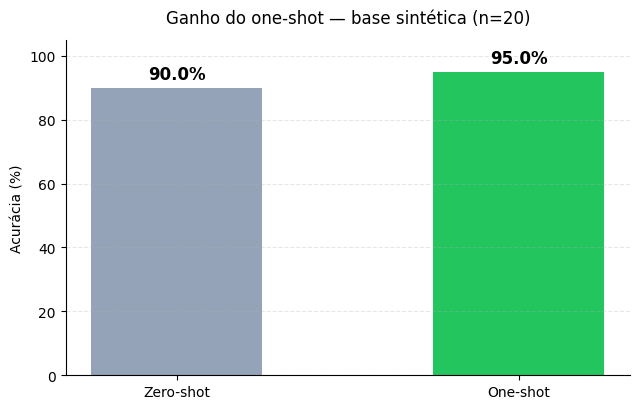

Ganho absoluto: 5.0 pontos percentuais
Redução relativa do erro: 50.0%


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.2))
tecnicas = ["Zero-shot", "One-shot"]
valores = [acc_zero * 100, acc_one * 100]
cores = ["#94a3b8", "#22c55e"]

barras = ax.bar(tecnicas, valores, color=cores, width=0.5)
for barra, valor in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 1.5, f"{valor:.1f}%",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 105)
ax.set_ylabel("Acurácia (%)")
ax.set_title(f"Ganho do one-shot — base sintética (n={len(df_resultados)})", fontsize=12, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Ganho absoluto: {(acc_one - acc_zero) * 100:.1f} pontos percentuais")
if acc_zero < 1:
    reducao_erro = (( (1 - acc_zero) - (1 - acc_one) ) / (1 - acc_zero)) * 100
    print(f"Redução relativa do erro: {reducao_erro:.1f}%")


## 6.2 Matriz de confusão

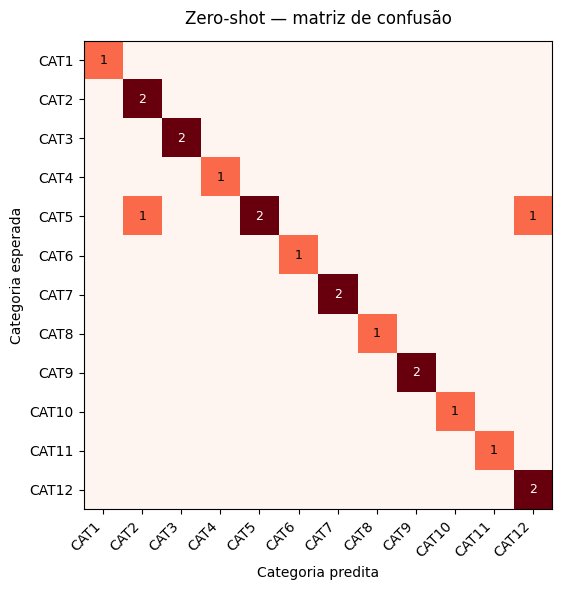

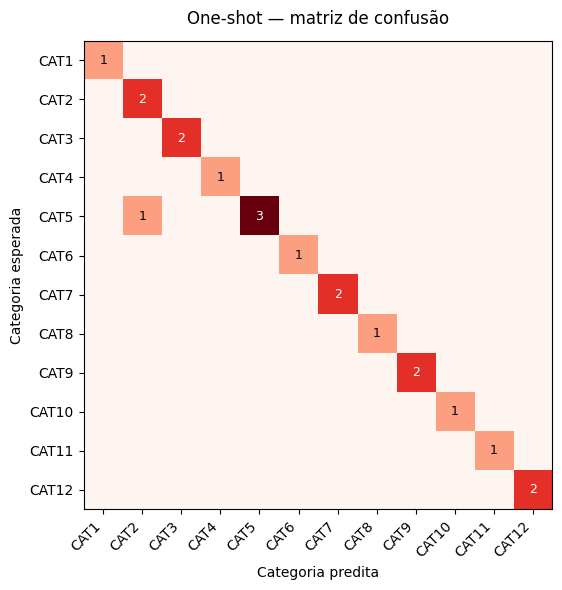

In [10]:
def plotar_matriz_confusao(df_r: pd.DataFrame, coluna_predita: str, titulo: str):
    categorias = sorted(
        set(df_r["esperado"]) | set(df_r[coluna_predita].dropna()),
        key=lambda c: int(c.replace("CAT", "")),
    )
    matriz = pd.crosstab(df_r["esperado"], df_r[coluna_predita]).reindex(
        index=categorias, columns=categorias, fill_value=0
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(matriz.values, cmap="Reds")

    ax.set_xticks(range(len(categorias)))
    ax.set_yticks(range(len(categorias)))
    ax.set_xticklabels(categorias, rotation=45, ha="right")
    ax.set_yticklabels(categorias)
    ax.set_xlabel("Categoria predita")
    ax.set_ylabel("Categoria esperada")
    ax.set_title(titulo, fontsize=12, pad=12)

    for i in range(len(categorias)):
        for j in range(len(categorias)):
            valor = matriz.values[i, j]
            if valor > 0:
                cor_texto = "white" if valor > matriz.values.max() / 2 else "black"
                ax.text(j, i, str(valor), ha="center", va="center", color=cor_texto, fontsize=9)

    plt.tight_layout()
    plt.show()


plotar_matriz_confusao(df_resultados, "zero_shot", "Zero-shot — matriz de confusão")
plotar_matriz_confusao(df_resultados, "one_shot", "One-shot — matriz de confusão")


## 6.3 Dispersão semântica (classificação livre)

Quantos rótulos diferentes o modelo usou para tickets da mesma categoria real —
sem taxonomia, é esperado que esse número seja alto, mesmo numa base sintética
pequena.


In [12]:
rotulos_distintos_geral = df_resultados["rotulo_livre"].str.lower().str.strip().nunique()
print(f"{rotulos_distintos_geral} rótulos distintos (normalizado) para {len(df_resultados)} tickets.\n")

print("Por categoria (só onde há mais de 1 ticket):")
for cat, grupo in df_resultados.groupby("esperado"):
    if len(grupo) > 1:
        distintos = grupo["rotulo_livre"].str.lower().str.strip().nunique()
        rotulos = grupo["rotulo_livre"].tolist()
        print(f"  {cat} ({len(grupo)} tickets): {distintos} rótulo(s) distinto(s)")


19 rótulos distintos (normalizado) para 20 tickets.

Por categoria (só onde há mais de 1 ticket):
  CAT12 (2 tickets): 2 rótulo(s) distinto(s)
  CAT2 (2 tickets): 2 rótulo(s) distinto(s)
  CAT3 (2 tickets): 1 rótulo(s) distinto(s)
  CAT5 (4 tickets): 4 rótulo(s) distinto(s)
  CAT7 (2 tickets): 2 rótulo(s) distinto(s)
  CAT9 (2 tickets): 2 rótulo(s) distinto(s)


## 6.4 Gerando o arquivo para a Prática 3

A categoria atribuída pela melhor estratégia avaliada (one-shot) é salva em
`saida/incidentes_classificados.csv`, alimentando a Prática 3.


In [ ]:
import os as _os

_os.makedirs("saida", exist_ok=True)

saida_pratica3 = df.merge(
    df_resultados[["id", "one_shot"]].rename(columns={"one_shot": "categoria_atribuida"}),
    on="id",
)[["id", "id_incidente", "texto", "categoria_atribuida"]]

saida_pratica3.to_csv("saida/incidentes_classificados.csv", index=False)
print(f"Salvo em saida/incidentes_classificados.csv ({len(saida_pratica3)} tickets).")
saida_pratica3.head()


## 7. Discussão

Três perguntas para levar em conta ao interpretar o resultado que você acabou
de gerar (o número pode variar de execução para execução — LLMs não são
perfeitamente determinísticos):

- **A acurácia do one-shot foi maior que a do zero-shot?** Se sim, quantos
  tickets exatamente foram corrigidos, e quantos, se algum, regrediram (um
  ticket que o zero-shot acertava e o one-shot passou a errar)? Compare a
  matriz de confusão das duas técnicas pra achar esses casos específicos.
- **O T001 foi corrigido?** Ele e o exemplo T017 compartilham o mesmo
  mecanismo técnico (amplificação de tráfego via serviço de rede mal
  configurado) — T017 foi escolhido como exemplo por causa disso. Se T001
  continuar errado mesmo assim, vale investigar por quê.
- **Algum erro persiste nas duas técnicas?** Historicamente, o T024 resiste a
  toda estratégia de prompt testada neste minicurso — o relato dele é vago
  demais ("atividade incomum", sem detalhe técnico) pra qualquer técnica
  recuperar informação que nunca esteve no texto original. Confirma se isso
  se repete na sua execução.
